<table style="background-color: transparent;">
    <tr style="background-color: transparent;">
        <td width="400px"><font size="15px" color="#76a596">Quinta<br>Escuela<br>de Verano</font></td>
        <td><img width="700" style="display:block; margin-left: auto; margin-right: auto;" src="https://images.claudiazm.xyz/ecc26/header.png"></td>
    </tr>
</table>

<p style="text-align:right; font-weight:bold;">Autora: Claudia Zendejas-Morales</p>

# <center> Pilares de la Computación Cuántica

## Contenido

1. [Tres pilares, una sola forma de computar](#1)
2. [Superposición](#2)
    1. [La fase también forma parte del estado](#2.1)
3. [Entrelazamiento](#3)
    1. [Superposición no siempre significa entrelazamiento](#3.1)
4. [Interferencia](#4)
    1. [Interferencia de ondas](#4.1)
    2. [Aplicar Hadamard al estado $|+\rangle$](#4.2)
    3. [Aplicar Hadamard al estado $|-\rangle$](#4.3)
    4. [Interferencia con dos qubits](#4.4)
5. [Cómo reconocer los pilares en un algoritmo](#5)
6. [Ejercicios](#6)
7. [Referencias](#7)

<a id="1"></a>
# 1. Tres pilares, una sola forma de computar

Los circuitos cuánticos aprovechan tres propiedades estrechamente relacionadas: **superposición, entrelazamiento e interferencia**. Conviene estudiarlas por separado para construir intuición, pero en un algoritmo suelen actuar juntas.

* La **superposición** permite representar alternativas mediante amplitudes complejas.
* El **entrelazamiento** permite que el estado del sistema completo no pueda separarse en estados independientes para cada qubit.
* La **interferencia** hace que distintas contribuciones a una amplitud se refuercen o se cancelen.

**Un algoritmo cuántico útil no obtiene una ventaja solo por "probar muchas respuestas a la vez"**. Debe controlar amplitudes y fases para que los caminos que favorecen una respuesta se refuercen y los que llevan a otras respuestas se reduzcan. Finalmente, la medición convierte el estado cuántico en información clásica.

<div style="color: #3c763d; background-color: #dff0d8; border: 1px solid #d6e9c6; border-radius: 4px; padding: 15px; margin-bottom: 20px;">
<strong>Una guía visual</strong><br><br>
Podemos imaginar que la superposición abre varios caminos, el entrelazamiento conecta lo que ocurre en esos caminos y la interferencia redistribuye sus amplitudes. Esta analogía es útil, pero los objetos que realmente evolucionan son números complejos y no ondas materiales que viajan dentro del circuito.
</div>

Usaremos simulaciones ideales para observar estados intermedios que normalmente no pueden inspeccionarse directamente en hardware. En un experimento real solo se obtiene el resultado de las mediciones y se requieren muchas ejecuciones para estimar sus probabilidades.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram

In [2]:
def graficar_amplitudes(estados, titulos):
    """Grafica las partes real e imaginaria de uno o varios vectores de estado."""
    if not isinstance(estados, (list, tuple)):
        estados = [estados]
    if isinstance(titulos, str):
        titulos = [titulos]

    fig, axes = plt.subplots(
        len(estados),
        1,
        figsize=(8, 3.3 * len(estados)),
        squeeze=False,
    )

    for ax, estado, titulo in zip(axes[:, 0], estados, titulos):
        amplitudes = np.asarray(estado.data)
        num_qubits = estado.num_qubits
        etiquetas = [
            f"|{indice:0{num_qubits}b}⟩"
            for indice in range(len(amplitudes))
        ]
        posiciones = np.arange(len(amplitudes), dtype=float)

        # Si solo una componente es visible, su barra queda centrada en la etiqueta.
        # Si ambas son visibles, el par se distribuye simétricamente alrededor de ella.
        ambas_visibles = (
            ~np.isclose(amplitudes.real, 0)
            & ~np.isclose(amplitudes.imag, 0)
        )
        desplazamiento = np.where(ambas_visibles, 0.18, 0.0)
        ancho = np.where(ambas_visibles, 0.36, 0.58)

        ax.bar(
            posiciones - desplazamiento,
            amplitudes.real,
            width=ancho,
            label="Parte real",
            color="#4c78a8",
        )
        ax.bar(
            posiciones + desplazamiento,
            amplitudes.imag,
            width=ancho,
            label="Parte imaginaria",
            color="#f58518",
        )
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xticks(posiciones, etiquetas)
        ax.set_ylim(-1.1, 1.1)
        ax.set_ylabel("Amplitud")
        ax.set_title(titulo)
        ax.grid(axis="y", alpha=0.25)
        ax.legend(loc="upper right")

    fig.tight_layout()
    plt.show()

<a id="2"></a>
# 2. Superposición

<div align="center">
<img width="900" style="display:block; margin-left: auto; margin-right: auto;" src="images/SuperpositionFromRy.gif">
</div>

Un qubit puede encontrarse en un estado

$$
|\psi\rangle=\alpha|0\rangle+\beta|1\rangle,
\qquad |\alpha|^2+|\beta|^2=1
$$

Los números complejos $\alpha$ y $\beta$ son **amplitudes**. Si medimos en la base computacional, obtenemos $0$ con probabilidad $|\alpha|^2$ y $1$ con probabilidad $|\beta|^2$.

La compuerta Hadamard permite crear dos superposiciones especialmente importantes:

$$
H|0\rangle=|+\rangle
=\frac{|0\rangle+|1\rangle}{\sqrt{2}}
$$

$$
H|1\rangle=|-\rangle
=\frac{|0\rangle-|1\rangle}{\sqrt{2}}
$$

En ambos casos las probabilidades de medir $0$ o $1$ son iguales, pero el signo relativo es diferente. Esa diferencia será fundamental para producir interferencia.

<div style="color: #31708f; background-color: #d9edf7; border: 1px solid #bce8f1; border-radius: 4px; padding: 15px; margin-bottom: 20px;">
<strong>Superposición no es desconocimiento clásico</strong><br><br>
Una moneda cubierta puede tener un valor definido que todavía desconocemos. En una superposición coherente, en cambio, las amplitudes conservan información de fase y pueden interferir. Por eso los estados $|+\rangle$ y $|-\rangle$ producen las mismas probabilidades al medirlos directamente en la base computacional, pero reaccionan de manera diferente ante otra compuerta Hadamard.
</div>

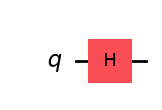

In [3]:
circ_superposicion = QuantumCircuit(1)
circ_superposicion.h(0)

display(circ_superposicion.draw("mpl"))

Estado inicial:


<IPython.core.display.Latex object>

Estado después de Hadamard:


<IPython.core.display.Latex object>

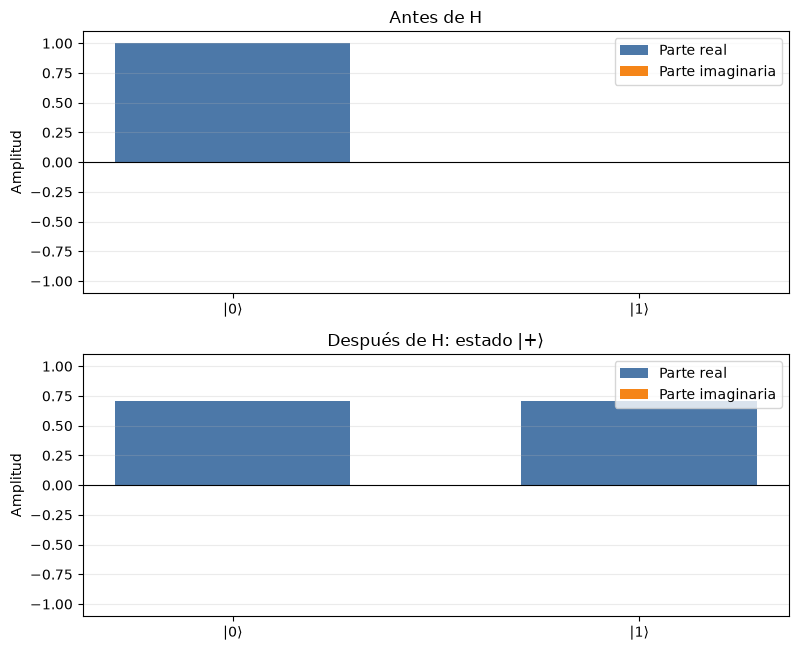

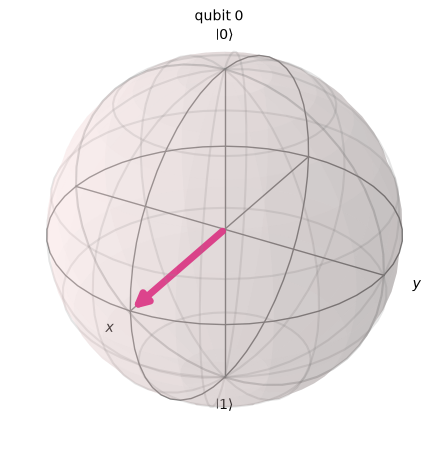

In [4]:
estado_inicial = Statevector.from_label("0")
estado_plus = Statevector.from_instruction(circ_superposicion)

print("Estado inicial:")
display(estado_inicial.draw("latex"))

print("Estado después de Hadamard:")
display(estado_plus.draw("latex"))

graficar_amplitudes(
    [estado_inicial, estado_plus],
    ["Antes de H", "Después de H: estado |+⟩"],
)

plot_bloch_multivector(estado_plus)

En la gráfica de amplitudes aparecen dos barras positivas de altura $1/\sqrt{2}$. Al elevar sus magnitudes al cuadrado obtenemos

$$
\left|\frac{1}{\sqrt{2}}\right|^2
=\frac{1}{2}
$$

por lo que cada resultado tiene probabilidad $1/2$. La esfera de Bloch muestra que el estado ya no apunta hacia $|0\rangle$, sino hacia el eje $+X$, que corresponde a $|+\rangle$.

<a id="2.1"></a>
## 2.1. La fase también forma parte del estado

Los estados

$$
|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}},
\qquad
|-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}}
$$

tienen la misma distribución de probabilidades en la base computacional. Sin embargo, no son el mismo estado: el término $|1\rangle$ tiene signo opuesto. Esa **fase relativa** determina cómo se combinarán sus amplitudes en operaciones posteriores.

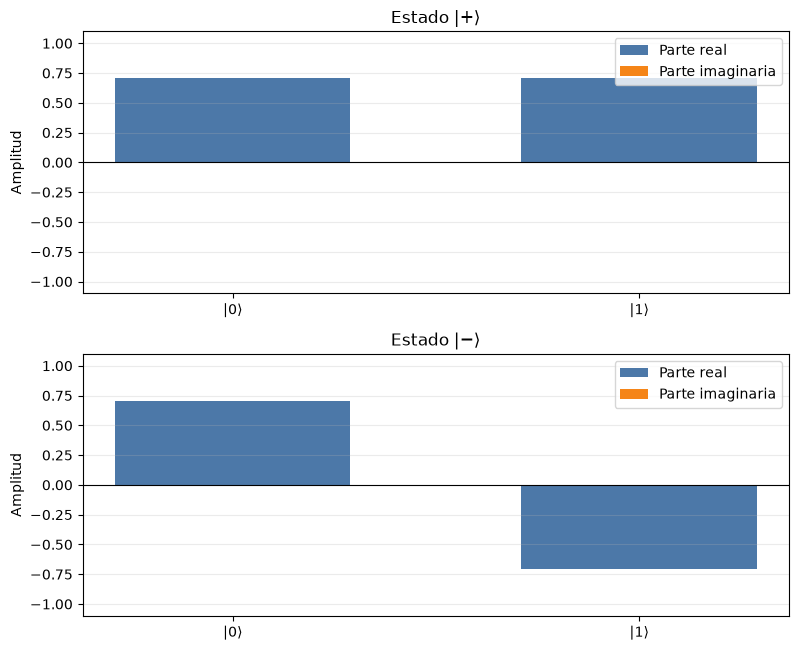

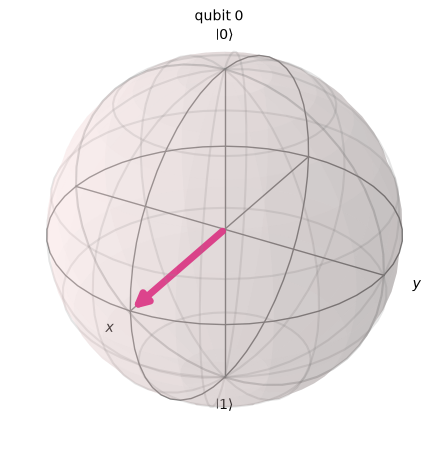

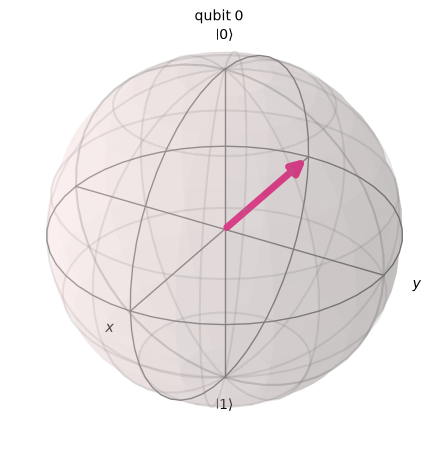

In [5]:
estado_plus = Statevector.from_label("+")
estado_menos = Statevector.from_label("-")

graficar_amplitudes(
    [estado_plus, estado_menos],
    ["Estado |+⟩", "Estado |−⟩"],
)

display(plot_bloch_multivector(estado_plus))
display(plot_bloch_multivector(estado_menos))

La probabilidad no muestra el signo de una amplitud. Para recuperar esa información necesitamos cambiar de base o hacer que distintas contribuciones interfieran. En las secciones siguientes veremos ambas ideas.

Veamos un ejemplo con los estados $|+\rangle$ y $|-\rangle$. Si los medimos directamente en la base computacional, ambos producen `0` y `1` con la misma probabilidad. Sin embargo, podemos colocar antes de la medición una compuerta personalizada que cambie la base en la que observamos el qubit. En el circuito, este procedimiento aparecerá dentro de una sola caja llamada **Cambio a base X**.

Medición de |+⟩ después del cambio de base:


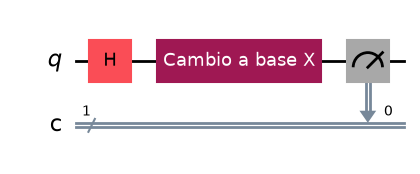

Medición de |−⟩ después del cambio de base:


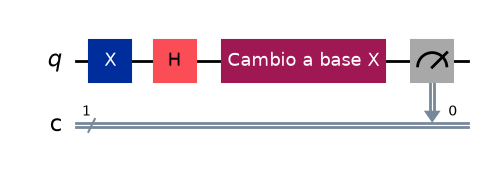

In [6]:
cambio_base_x = QuantumCircuit(1, name="Base X")
cambio_base_x.h(0)
compuerta_cambio_base_x = cambio_base_x.to_gate(
    label="Cambio a base X"
)

circ_mas_base_x = QuantumCircuit(1, 1)
circ_mas_base_x.h(0)
circ_mas_base_x.append(compuerta_cambio_base_x, [0])
circ_mas_base_x.measure(0, 0)

circ_menos_base_x = QuantumCircuit(1, 1)
circ_menos_base_x.x(0)
circ_menos_base_x.h(0)
circ_menos_base_x.append(compuerta_cambio_base_x, [0])
circ_menos_base_x.measure(0, 0)

print("Medición de |+⟩ después del cambio de base:")
display(circ_mas_base_x.draw("mpl"))

print("Medición de |−⟩ después del cambio de base:")
display(circ_menos_base_x.draw("mpl"))

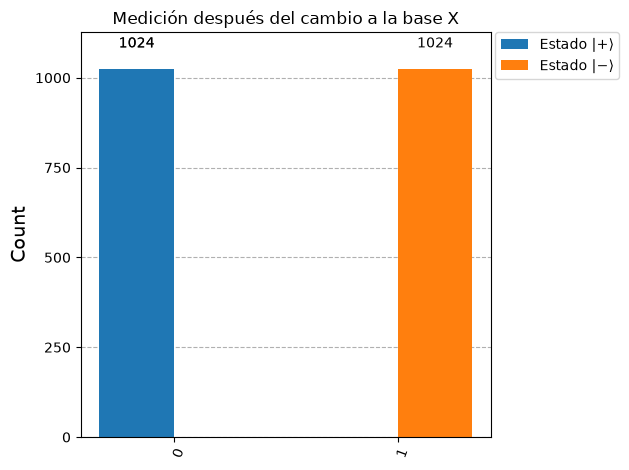

In [7]:
sampler_base_x = StatevectorSampler(seed=123)
shots_base_x = 1024

resultados_base_x = sampler_base_x.run(
    [
        (circ_mas_base_x, None, shots_base_x),
        (circ_menos_base_x, None, shots_base_x),
    ]
).result()

conteos_mas_base_x = resultados_base_x[0].data.c.get_counts()
conteos_menos_base_x = resultados_base_x[1].data.c.get_counts()

plot_histogram(
    [conteos_mas_base_x, conteos_menos_base_x],
    legend=["Estado |+⟩", "Estado |−⟩"],
    title="Medición después del cambio a la base X",
)

Ahora los resultados sí permiten distinguir los estados: $|+\rangle$ produce `0`, mientras que $|-\rangle$ produce `1`. El signo relativo que era invisible al medir directamente se convirtió en un resultado observable gracias al cambio de base. No reconstruimos todas las amplitudes con una sola medición, pero elegimos una base en la que la diferencia que nos interesa queda expuesta.

<details>
<summary><strong>¿Cómo funcionó el cambio de base?</strong></summary>
<br>

La medición habitual distingue los estados de la base computacional, $\{|0\rangle,|1\rangle\}$. Para medir en la base $X$, $\{|+\rangle,|-\rangle\}$, la caja aplica una compuerta Hadamard antes de la medición. Esto funciona porque

$$
H|+\rangle=|0\rangle,\qquad H|-\rangle=|1\rangle
$$

Por lo tanto, la medición computacional realizada después de $H$ equivale a preguntar si el estado original era $|+\rangle$ o $|-\rangle$. La fase relativa se transforma en una diferencia de probabilidades que sí podemos observar.

La base se elige según la propiedad que deseamos estudiar. Además de la base computacional y la base $X$, existen, por ejemplo, la base $Y$, formada por $|+i\rangle$ y $|-i\rangle$, y la **base de Bell** para sistemas de dos qubits.

</details>

<a id="3"></a>
# 3. Entrelazamiento

<div align="center">
<img width="900" style="display:block; margin-left: auto; margin-right: auto;" src="images/EntanglementCorrelations.gif">
</div>

Dos qubits están entrelazados cuando su estado conjunto no puede escribirse como un producto de estados individuales:

$$
|\psi\rangle\neq|\psi_1\rangle\otimes|\psi_2\rangle
$$

Un ejemplo es el estado de Bell

$$
|\Phi^+\rangle
=\frac{|00\rangle+|11\rangle}{\sqrt{2}}
$$

El sistema completo tiene una descripción bien definida, pero no podemos asignar a cada qubit un estado puro independiente. Si medimos ambos qubits en la base computacional, cada uno parece aleatorio por separado, mientras que sus resultados están perfectamente correlacionados.

En Qiskit, los estados de dos qubits se escriben como $|q_1q_0\rangle$. Partiendo de $|00\rangle$, aplicamos Hadamard al qubit $q_0$:

$$
|00\rangle
\xrightarrow{H_{q_0}}
\frac{|00\rangle+|01\rangle}{\sqrt{2}}
$$

Todavía podemos separar el estado:

$$
\frac{|00\rangle+|01\rangle}{\sqrt{2}}
=|0\rangle_{q_1}\otimes|+\rangle_{q_0}
$$

Después, una CNOT con $q_0$ como control y $q_1$ como objetivo transforma $|01\rangle$ en $|11\rangle$:

$$
\frac{|00\rangle+|01\rangle}{\sqrt{2}}
\xrightarrow{\mathrm{CNOT}_{q_0\rightarrow q_1}}
\frac{|00\rangle+|11\rangle}{\sqrt{2}}
$$

Ahora ya no es posible factorizar el estado en dos estados de un qubit.

Después de crear la superposición:


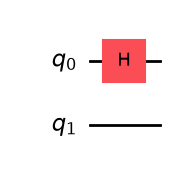

Después de entrelazar los qubits:


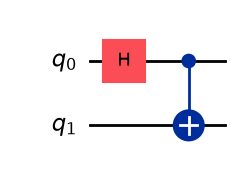

In [8]:
circ_despues_h = QuantumCircuit(2)
circ_despues_h.h(0)

circ_bell = circ_despues_h.copy()
circ_bell.cx(0, 1)

print("Después de crear la superposición:")
display(circ_despues_h.draw("mpl"))

print("Después de entrelazar los qubits:")
display(circ_bell.draw("mpl"))

Estado después de H:


<IPython.core.display.Latex object>

Estado después de CNOT:


<IPython.core.display.Latex object>

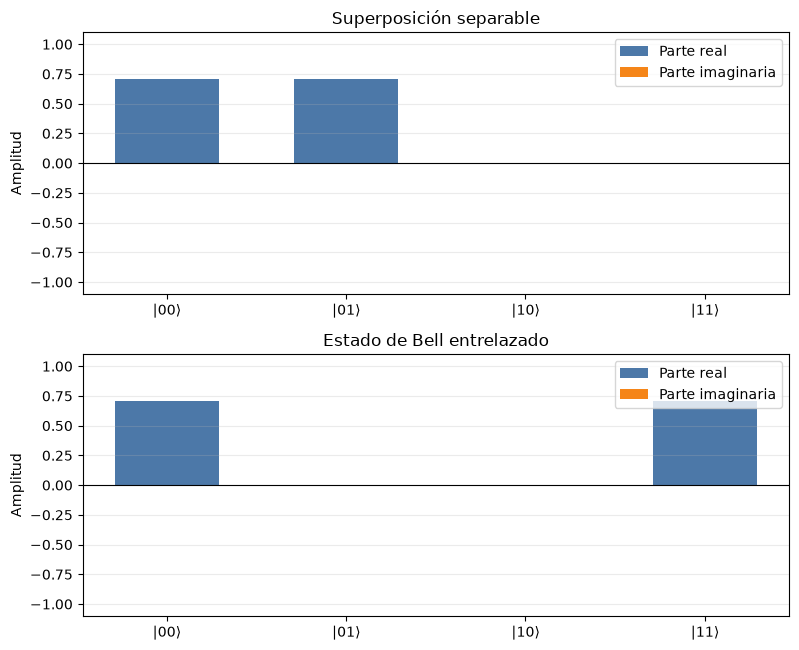

In [9]:
estado_despues_h = Statevector.from_instruction(circ_despues_h)
estado_bell = Statevector.from_instruction(circ_bell)

print("Estado después de H:")
display(estado_despues_h.draw("latex"))

print("Estado después de CNOT:")
display(estado_bell.draw("latex"))

graficar_amplitudes(
    [estado_despues_h, estado_bell],
    ["Superposición separable", "Estado de Bell entrelazado"],
)

<a id="3.1"></a>
## 3.1. Superposición no siempre significa entrelazamiento

Comparemos dos estados:

$$
|+\rangle|+\rangle
=\frac{|00\rangle+|01\rangle+|10\rangle+|11\rangle}{2}
$$

$$
|\Phi^+\rangle
=\frac{|00\rangle+|11\rangle}{\sqrt{2}}
$$

El primero contiene cuatro términos, pero es un producto de dos estados independientes. El segundo solo contiene dos términos, pero no puede factorizarse. La cantidad de términos de una expresión no determina si existe entrelazamiento.

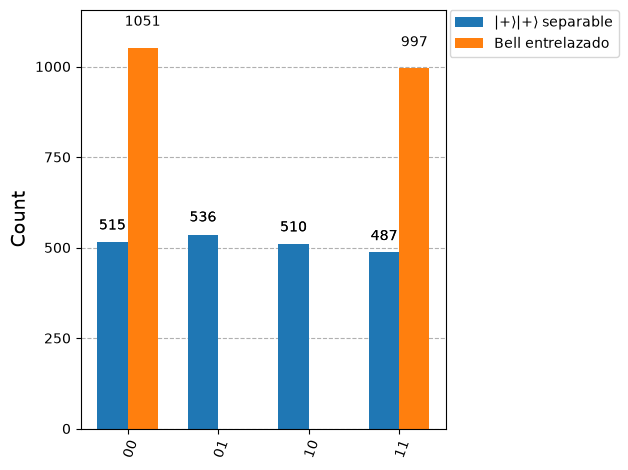

In [10]:
circ_producto = QuantumCircuit(2)
circ_producto.h([0, 1])

sampler = StatevectorSampler(seed=123)
shots = 2048

circ_producto_medido = circ_producto.copy()
circ_producto_medido.measure_all()

circ_bell_medido = circ_bell.copy()
circ_bell_medido.measure_all()

resultado_producto = sampler.run(
    [(circ_producto_medido, None, shots)]
).result()[0]
resultado_bell = sampler.run(
    [(circ_bell_medido, None, shots)]
).result()[0]

conteos_producto = resultado_producto.data.meas.get_counts()
conteos_bell = resultado_bell.data.meas.get_counts()

plot_histogram(
    [conteos_producto, conteos_bell],
    legend=["|+⟩|+⟩ separable", "Bell entrelazado"],
)

En el estado separable aparecen las cuatro cadenas porque cada qubit se comporta de forma independiente. En el estado de Bell solo aparecen $00$ y $11$: cada resultado individual es aleatorio, pero los dos resultados coinciden.

<div style="color: #31708f; background-color: #d9edf7; border: 1px solid #bce8f1; border-radius: 4px; padding: 15px; margin-top: 15px; margin-bottom: 20px;">
<strong>Una correlación no basta para demostrar entrelazamiento</strong><br><br>
Una mezcla clásica que produzca $00$ la mitad de las veces y $11$ la otra mitad tendría el mismo histograma en esta base. Para distinguirla de un estado de Bell se necesitan mediciones en otras bases, como $X$ y $Y$, tal como se estudió con los valores esperados de observables.
</div>

<details>
<summary><strong>¿Cómo se separa el estado con cuatro términos?</strong></summary>
<br>

Partimos del estado completo:

$$
\frac{|00\rangle+|01\rangle+|10\rangle+|11\rangle}{2}
$$

Primero agrupamos los términos de acuerdo con el estado del primer qubit:

$$
\frac{1}{2}\left[
\left(|00\rangle+|01\rangle\right)
+\left(|10\rangle+|11\rangle\right)
\right]
$$

En el primer grupo, el primer qubit siempre es $|0\rangle$; en el segundo, siempre es $|1\rangle$. Por lo tanto, podemos escribir:

$$
\frac{1}{2}\left[
|0\rangle\otimes\left(|0\rangle+|1\rangle\right)
+|1\rangle\otimes\left(|0\rangle+|1\rangle\right)
\right]
$$

Los dos términos contienen el mismo estado para el segundo qubit, así que lo factorizamos:

$$
\frac{1}{2}
\left(|0\rangle+|1\rangle\right)
\otimes
\left(|0\rangle+|1\rangle\right)
$$

Finalmente, distribuimos el factor $1/2$ como $1/\sqrt{2}$ para cada qubit:

$$
\left(\frac{|0\rangle+|1\rangle}{\sqrt{2}}\right)
\otimes
\left(\frac{|0\rangle+|1\rangle}{\sqrt{2}}\right)
=|+\rangle\otimes|+\rangle
$$

Hemos escrito el estado completo como el producto tensorial de dos estados individuales. Por eso es **separable** y no está entrelazado, aunque su expresión desarrollada contenga cuatro términos.

</details>

<a id="4"></a>
# 4. Interferencia

La interferencia ocurre cuando varias contribuciones llegan a la misma amplitud final. Como las amplitudes pueden ser positivas, negativas o complejas, sus contribuciones pueden:

* **reforzarse**, mediante interferencia constructiva
* **cancelarse**, mediante interferencia destructiva

Solo después de sumar las amplitudes se calcula la probabilidad. Esta es la razón por la que no podemos tratar un circuito cuántico como si únicamente transportara probabilidades clásicas.

<div align="center">
<img width="900" style="display:block; margin-left: auto; margin-right: auto;" src="images/ConstructiveInterference.gif">
</div>

<div align="center">
<img width="900" style="display:block; margin-left: auto; margin-right: auto;" src="images/DestructiveInterference.gif">
</div>

<div align="center">
<img width="900" style="display:block; margin-left: auto; margin-right: auto;" src="images/QuantumInterference.gif">
</div>

<a id="4.1"></a>
## 4.1. Interferencia de ondas

Las ondas clásicas ofrecen una analogía visual. Dos ondas con la misma fase se suman y producen una amplitud mayor. Si una tiene fase opuesta, sus valores se cancelan punto por punto.

En computación cuántica no sumamos alturas de ondas físicas, sino amplitudes complejas asociadas con estados base. La idea algebraica de sumar contribuciones con signo y fase sí es la misma.

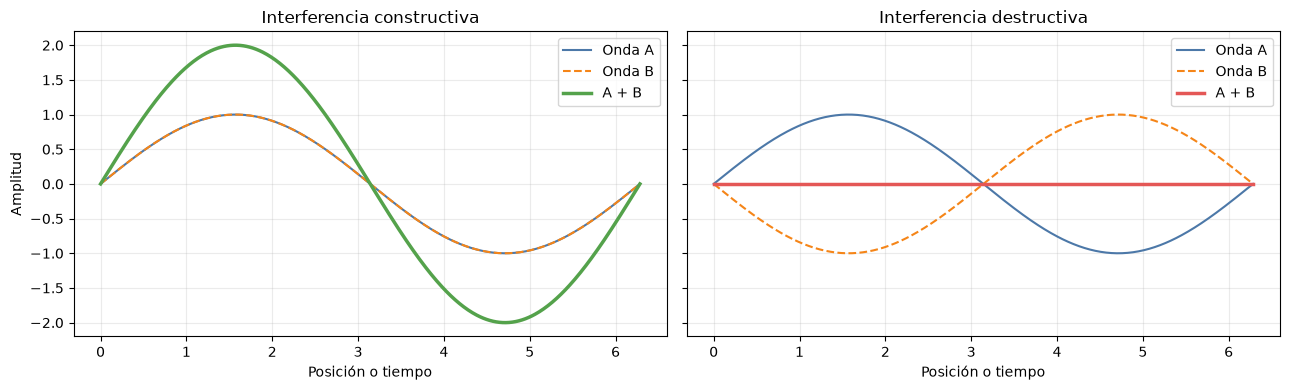

In [11]:
x = np.linspace(0, 2 * np.pi, 500)
onda = np.sin(x)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

axes[0].plot(x, onda, label="Onda A", color="#4c78a8")
axes[0].plot(x, onda, "--", label="Onda B", color="#f58518")
axes[0].plot(x, 2 * onda, label="A + B", color="#54a24b", linewidth=2.5)
axes[0].set_title("Interferencia constructiva")
axes[0].set_xlabel("Posición o tiempo")
axes[0].set_ylabel("Amplitud")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(x, onda, label="Onda A", color="#4c78a8")
axes[1].plot(x, -onda, "--", label="Onda B", color="#f58518")
axes[1].plot(x, np.zeros_like(x), label="A + B", color="#e45756", linewidth=2.5)
axes[1].set_title("Interferencia destructiva")
axes[1].set_xlabel("Posición o tiempo")
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
plt.show()

<a id="4.2"></a>
## 4.2. Aplicar Hadamard al estado $|+\rangle$

Recordemos que

$$
|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}}
$$

Aplicamos Hadamard de manera lineal a cada término:

$$
\begin{aligned}
H|+\rangle
&=\frac{1}{\sqrt{2}}\left(H|0\rangle+H|1\rangle\right)\\
&=\frac{1}{\sqrt{2}}
\left(
\frac{|0\rangle+|1\rangle}{\sqrt{2}}
+
\frac{|0\rangle-|1\rangle}{\sqrt{2}}
\right)\\
&=\frac{1}{2}
\left(
|0\rangle+|1\rangle+|0\rangle-|1\rangle
\right)\\
&=\frac{1}{2}\left(2|0\rangle\right)\\
&=|0\rangle
\end{aligned}
$$

Las dos contribuciones a $|0\rangle$ se suman constructivamente. Las contribuciones $+|1\rangle$ y $-|1\rangle$ se cancelan mediante interferencia destructiva.

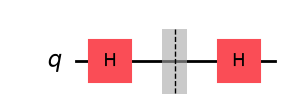

Después de la primera H:


<IPython.core.display.Latex object>

Después de la segunda H:


<IPython.core.display.Latex object>

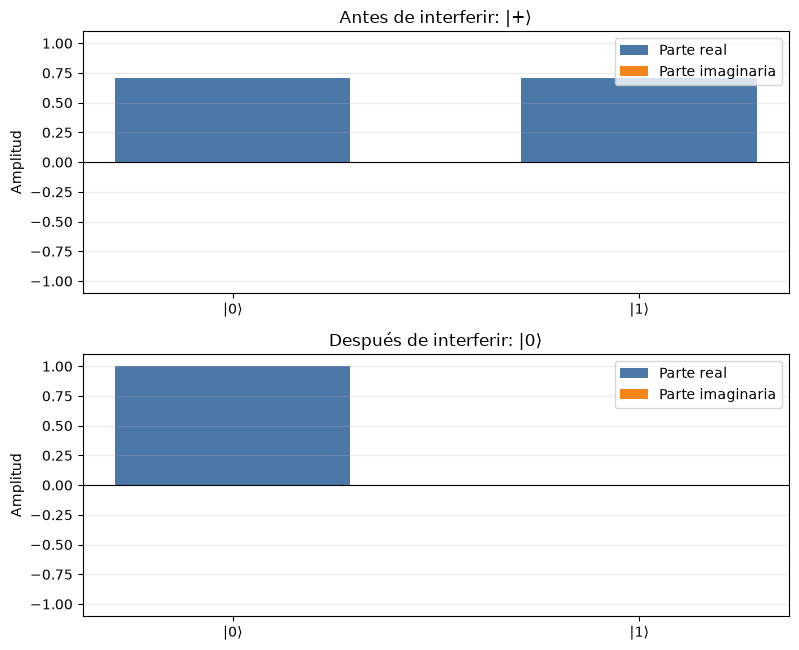

In [12]:
circ_h_sobre_plus = QuantumCircuit(1)
circ_h_sobre_plus.h(0)
circ_h_sobre_plus.barrier()
circ_h_sobre_plus.h(0)

# Construimos cada etapa por separado para observarla.
etapa_plus = QuantumCircuit(1)
etapa_plus.h(0)

etapa_final_plus = etapa_plus.copy()
etapa_final_plus.h(0)

estado_plus = Statevector.from_instruction(etapa_plus)
estado_final_plus = Statevector.from_instruction(etapa_final_plus)

display(circ_h_sobre_plus.draw("mpl"))

print("Después de la primera H:")
display(estado_plus.draw("latex"))

print("Después de la segunda H:")
display(estado_final_plus.draw("latex"))

graficar_amplitudes(
    [estado_plus, estado_final_plus],
    ["Antes de interferir: |+⟩", "Después de interferir: |0⟩"],
)

<div style="color: #3c763d; background-color: #dff0d8; border: 1px solid #d6e9c6; border-radius: 4px; padding: 15px; margin-bottom: 20px;">
<strong>Qué debe observarse</strong><br><br>
La segunda Hadamard no "mide" el estado ni elige una de las dos alternativas. Mezcla nuevamente sus amplitudes. El resultado determinista $|0\rangle$ aparece porque las contribuciones se suman para $|0\rangle$ y se cancelan para $|1\rangle$.
</div>

<a id="4.3"></a>
## 4.3. Aplicar Hadamard al estado $|-\rangle$

Para el estado con fase relativa negativa ocurre lo contrario:

$$
\begin{aligned}
H|-\rangle
&=\frac{1}{\sqrt{2}}\left(H|0\rangle-H|1\rangle\right)\\
&=\frac{1}{2}
\left(
|0\rangle+|1\rangle-|0\rangle+|1\rangle
\right)\\
&=|1\rangle
\end{aligned}
$$

Ahora las contribuciones a $|0\rangle$ se cancelan y las contribuciones a $|1\rangle$ se refuerzan. Hadamard convierte así información de fase en una diferencia observable en la base computacional.

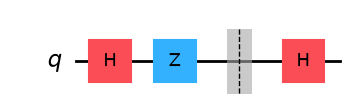

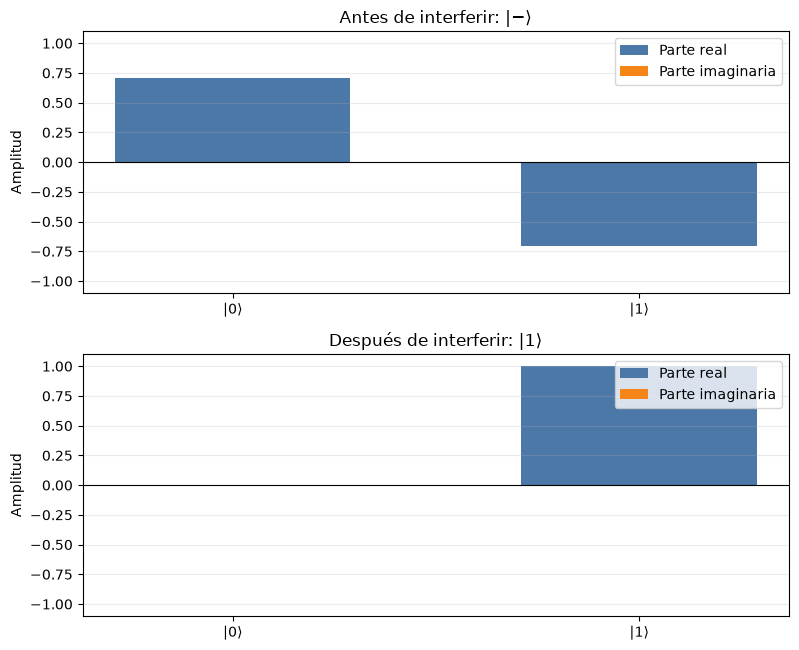

In [13]:
etapa_menos = QuantumCircuit(1)
etapa_menos.h(0)
etapa_menos.z(0)

etapa_final_menos = etapa_menos.copy()
etapa_final_menos.h(0)

estado_menos = Statevector.from_instruction(etapa_menos)
estado_final_menos = Statevector.from_instruction(etapa_final_menos)

circ_h_sobre_menos = etapa_menos.copy()
circ_h_sobre_menos.barrier()
circ_h_sobre_menos.h(0)

display(circ_h_sobre_menos.draw("mpl"))

graficar_amplitudes(
    [estado_menos, estado_final_menos],
    ["Antes de interferir: |−⟩", "Después de interferir: |1⟩"],
)

Los estados $|+\rangle$ y $|-\rangle$ tenían las mismas probabilidades antes de la última Hadamard. Después de hacerlos interferir, uno produce $|0\rangle$ y el otro produce $|1\rangle$. Los algoritmos cuánticos explotan precisamente este tipo de transformación de fases en amplitudes medibles.

<a id="4.4"></a>
## 4.4. Interferencia con dos qubits

Veamos una versión mínima de **amplificación de amplitud** con dos qubits. El objetivo será favorecer el estado $|11\rangle$:

1. Hadamard crea una superposición uniforme de cuatro estados.
2. Una operación $CZ$ cambia el signo de la amplitud de $|11\rangle$. Esta operación funciona como un oráculo que marca la respuesta, pero todavía no cambia las probabilidades. (Más detalles al estudiar el algoritmo de Grover)
3. Un operador de difusión hace interferir las amplitudes alrededor de su promedio.
4. La amplitud de $|11\rangle$ queda con magnitud $1$ y las demás se cancelan.

Este ejemplo anticipa la idea central del algoritmo de Grover sin entrar todavía en su análisis general.

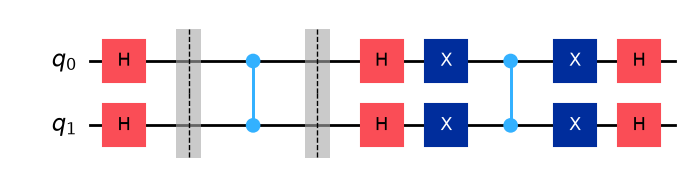

In [14]:
preparacion_2q = QuantumCircuit(2)
preparacion_2q.h([0, 1])

marcado_11 = preparacion_2q.copy()
marcado_11.cz(0, 1)

amplificacion_11 = marcado_11.copy()
amplificacion_11.h([0, 1])
amplificacion_11.x([0, 1])
amplificacion_11.cz(0, 1)
amplificacion_11.x([0, 1])
amplificacion_11.h([0, 1])

circuito_completo_2q = QuantumCircuit(2)
circuito_completo_2q.h([0, 1])
circuito_completo_2q.barrier()
circuito_completo_2q.cz(0, 1)
circuito_completo_2q.barrier()
circuito_completo_2q.h([0, 1])
circuito_completo_2q.x([0, 1])
circuito_completo_2q.cz(0, 1)
circuito_completo_2q.x([0, 1])
circuito_completo_2q.h([0, 1])

display(circuito_completo_2q.draw("mpl"))

Superposición uniforme:


<IPython.core.display.Latex object>

Después de marcar la fase de |11⟩:


<IPython.core.display.Latex object>

Después de la interferencia:


<IPython.core.display.Latex object>

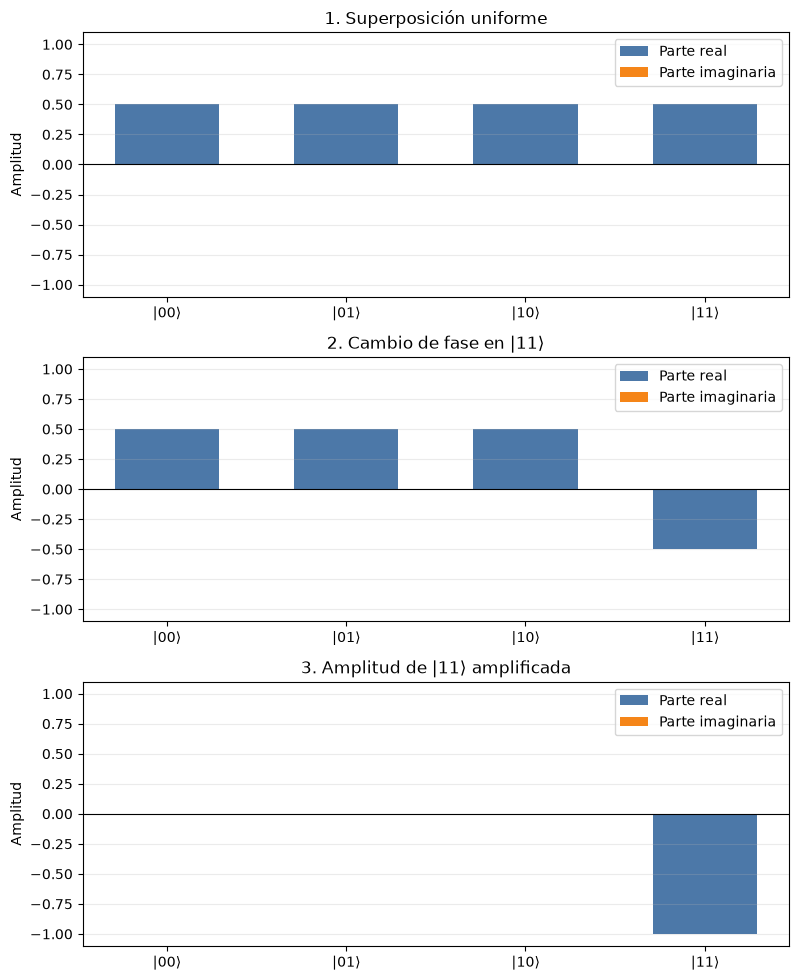

In [15]:
estado_uniforme = Statevector.from_instruction(preparacion_2q)
estado_marcado = Statevector.from_instruction(marcado_11)
estado_amplificado = Statevector.from_instruction(amplificacion_11)

print("Superposición uniforme:")
display(estado_uniforme.draw("latex"))

print("Después de marcar la fase de |11⟩:")
display(estado_marcado.draw("latex"))

print("Después de la interferencia:")
display(estado_amplificado.draw("latex"))

graficar_amplitudes(
    [estado_uniforme, estado_marcado, estado_amplificado],
    [
        "1. Superposición uniforme",
        "2. Cambio de fase en |11⟩",
        "3. Amplitud de |11⟩ amplificada",
    ],
)

{'11': 1024}


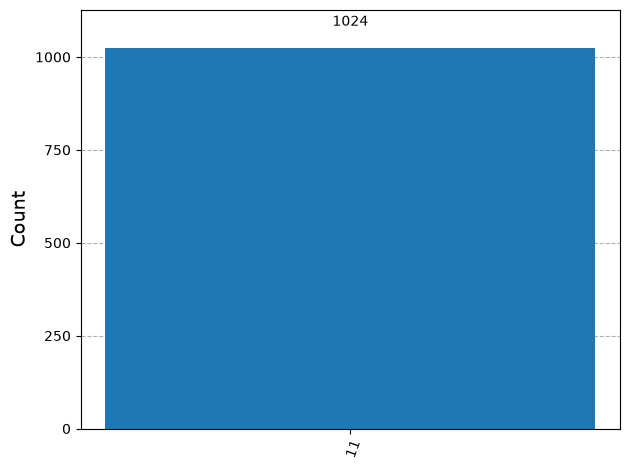

In [16]:
amplificacion_11_medida = amplificacion_11.copy()
amplificacion_11_medida.measure_all()

resultado_amplificacion = sampler.run(
    [(amplificacion_11_medida, None, 1024)]
).result()[0]

conteos_amplificacion = resultado_amplificacion.data.meas.get_counts()
print(conteos_amplificacion)
plot_histogram(conteos_amplificacion)

El signo final puede ser $-|11\rangle$ en lugar de $|11\rangle$. Esta diferencia es una **fase global** y no modifica ninguna probabilidad de medición.

<div style="color: #3c763d; background-color: #dff0d8; border: 1px solid #d6e9c6; border-radius: 4px; padding: 15px; margin-top: 15px; margin-bottom: 20px;">
<strong>Los tres pilares en el mismo circuito</strong><br><br>
La primera capa de Hadamard crea <strong>superposición</strong>. El cambio de fase mediante CZ produce un estado en el que las amplitudes de los dos qubits ya no se separan, por lo que aparece <strong>entrelazamiento</strong>. La difusión provoca <strong>interferencia</strong> y concentra la probabilidad en la respuesta marcada.
</div>

<a id="5"></a>
# 5. Cómo reconocer los pilares en un algoritmo

Cuando estudiemos un algoritmo cuántico, podemos leer sus etapas con las siguientes preguntas:

| Pilar | Pregunta para leer el circuito | Señal frecuente |
|:--|:--|:--|
| **Superposición** | ¿Qué alternativas reciben amplitud? | Capas de Hadamard o rotaciones que distribuyen amplitudes |
| **Entrelazamiento** | ¿Qué qubits dejan de poder describirse de forma independiente? | Compuertas de varios qubits, como CNOT, CZ o compuertas controladas |
| **Interferencia** | ¿Qué caminos llegan al mismo estado final y cómo se combinan sus fases? | Cambios de fase seguidos por Hadamard, transformadas o difusión |
| **Medición** | ¿Qué información clásica puede extraerse al final? | Bits clásicos, conteos, probabilidades o valores esperados |

No todas las compuertas controladas crean entrelazamiento para cualquier entrada, y no toda superposición conduce a una ventaja. Lo importante es la evolución completa de las amplitudes.

<div style="color: #31708f; background-color: #d9edf7; border: 1px solid #bce8f1; border-radius: 4px; padding: 15px; margin-bottom: 20px;">
<strong>Una frase para recordar cada pilar</strong><br><br>
<strong>Superposición:</strong> hay amplitudes asociadas con varias alternativas.<br>
<strong>Entrelazamiento:</strong> el estado completo contiene información que no pertenece a cada qubit por separado.<br>
<strong>Interferencia:</strong> las amplitudes que llegan a una misma alternativa se suman antes de convertirse en probabilidades.
</div>

<a id="6"></a>
# 6. Ejercicios

1. Calcula $H|0\rangle$, $H|1\rangle$, $H|+\rangle$ y $H|-\rangle$. Indica en qué casos observas interferencia constructiva y destructiva.

2. Determina cuáles de los siguientes estados son separables y factorízalos cuando sea posible:

   $$
   \frac{|00\rangle+|01\rangle}{\sqrt{2}},
   \qquad
   \frac{|00\rangle+|11\rangle}{\sqrt{2}},
   \qquad
   \frac{|00\rangle+|01\rangle+|10\rangle+|11\rangle}{2}
   $$

3. Los estados $|+\rangle$ y $|-\rangle$ producen la misma distribución al medirse directamente en la base computacional. Diseña un circuito que permita distinguirlos con certeza.

4. Modifica el ejemplo de amplificación de dos qubits para marcar $|00\rangle$ en lugar de $|11\rangle$. Verifica el resultado con un vector de estado y con 1024 *shots*.

5. Explica con tus propias palabras por qué cambiar el signo de una amplitud puede ser útil aunque no cambie inmediatamente las probabilidades.

<details>
<summary><strong>Posibles soluciones</strong></summary>

1. Se obtiene $H|0\rangle=|+\rangle$, $H|1\rangle=|-\rangle$, $H|+\rangle=|0\rangle$ y $H|-\rangle=|1\rangle$. En los dos últimos casos las contribuciones se refuerzan para un estado base y se cancelan para el otro.

2. El primer estado es $|0\rangle|+\rangle$ y el tercero es $|+\rangle|+\rangle$, por lo que son separables. El estado $(|00\rangle+|11\rangle)/\sqrt{2}$ es entrelazado.

3. Basta aplicar Hadamard antes de medir: $H|+\rangle=|0\rangle$ y $H|-\rangle=|1\rangle$.

4. Para marcar $|00\rangle$, se pueden aplicar compuertas $X$ a ambos qubits antes y después de $CZ$ en el oráculo. El mismo operador de difusión concentra después la amplitud en $|00\rangle$.

5. Una fase relativa puede convertirse posteriormente en una diferencia de amplitudes mediante interferencia. Solo entonces la diferencia aparece en las probabilidades de medición.

</details>

<a id="7"></a>
# 7. Referencias

## Documentación y recursos de aprendizaje

- IBM Quantum. [Fundamentos de la computación cuántica: superposición, entrelazamiento e interferencia](https://quantum.cloud.ibm.com/learning/en/courses/quantum-business-foundations/quantum-computing-fundamentals).
- IBM Quantum. [Quantum Coins: módulo sobre superposición e interferencia](https://quantum.cloud.ibm.com/learning/en/modules/quantum-mechanics/superposition-with-qiskit).
- IBM Quantum. [Curso: fundamentos de la información cuántica](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information).
- IBM Quantum. [Conceptos básicos de mecánica cuántica aplicados a circuitos](https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today/quantum-mechanics-basics).
- IBM Quantum. [Simulación exacta con las primitivas de Qiskit SDK](https://quantum.cloud.ibm.com/docs/en/guides/simulate-with-qiskit-sdk-primitives).
- IBM Quantum. [Referencia de `Statevector`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Statevector).
- IBM Quantum. [Algoritmo de Grover y amplificación de amplitud](https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/grovers-algorithm).

## Libros y artículos

- Nielsen, M. A. y Chuang, I. L. (2010). *Quantum Computation and Quantum Information: 10th Anniversary Edition*. Cambridge University Press. [https://doi.org/10.1017/CBO9780511976667](https://doi.org/10.1017/CBO9780511976667).
- Bell, J. S. (1964). *On the Einstein Podolsky Rosen paradox*. *Physics Physique Fizika*, 1, 195-200. [https://doi.org/10.1103/PhysicsPhysiqueFizika.1.195](https://doi.org/10.1103/PhysicsPhysiqueFizika.1.195).
- Greenberger, D. M., Horne, M. A., Shimony, A. y Zeilinger, A. (1990). *Bell's theorem without inequalities*. *American Journal of Physics*, 58, 1131-1143. [https://doi.org/10.1119/1.16243](https://doi.org/10.1119/1.16243).